In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\hashr\Downloads\Salary_Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [4]:
df.describe()


,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [5]:
df.columns=df.columns.str.replace(" ",'_')

In [6]:
df

,Age,Gender,Education_Level,Job_Title,Years_of_Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [7]:
df.isna().sum()

Age                    2
Gender                 2
Education_Level        3
Job_Title              2
Years_of_Experience    3
Salary                 5
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum()

Age                    0
Gender                 0
Education_Level        0
Job_Title              0
Years_of_Experience    0
Salary                 0
dtype: int64

In [10]:
df.Age=df.Age.astype(int)

In [11]:
df.dtypes

Age                      int64
Gender                  object
Education_Level         object
Job_Title               object
Years_of_Experience    float64
Salary                 float64
dtype: object

In [12]:
df.to_csv("salary_data_clean.csv", index=False)

In [13]:
df.Job_Title.value_counts().sample(23)

Job_Title
Senior HR Manager                   3
UX Designer                         1
Senior Marketing Coordinator        3
Senior Marketing Manager            9
Senior Consultant                   1
Director of Human Resources         2
Senior Account Executive            1
Senior Sales Representative         2
Senior Account Manager              1
Financial Advisor                   1
Marketing Director                 64
Director of Finance                 2
Senior Business Analyst            10
Junior Software Engineer           51
Data Entry Clerk                    1
Senior IT Consultant                2
Office Manager                      1
IT Support                          1
Product Manager                   313
Junior Copywriter                   1
Business Analyst                    2
Human Resources Director            1
Director of Product Management      1
Name: count, dtype: int64

In [14]:
# Removing the job titles that have low value_count
Job_Title_count = df['Job_Title'].value_counts()
Job_Title_edited = Job_Title_count[Job_Title_count<=25]
Job_Title_edited.count()

np.int64(142)

In [15]:
# Omitting titles with fewer than 25 counts
df['Job_Title'] = df['Job_Title'].apply(lambda x: 'Others' if x in Job_Title_edited else x )
df.Job_Title.unique()

array(['Software Engineer', 'Data Analyst', 'Others', 'Sales Associate',
       'Marketing Analyst', 'Product Manager', 'Sales Manager',
       'Marketing Coordinator', 'Software Developer', 'Financial Analyst',
       'Operations Manager', 'Marketing Manager', 'Sales Director',
       'Financial Manager', 'Product Designer', 'Data Scientist',
       'Sales Executive', 'Director of Marketing',
       'Senior Data Scientist', 'Digital Marketing Manager',
       'Web Developer', 'Research Director', 'Senior Software Engineer',
       'Content Marketing Manager', 'Sales Representative',
       'Research Scientist', 'Junior Software Developer',
       'Junior Web Developer', 'Junior HR Generalist',
       'Senior HR Generalist', 'Senior Research Scientist',
       'Junior Sales Representative', 'Junior Marketing Manager',
       'Senior Product Marketing Manager', 'Junior Software Engineer',
       'Senior Human Resources Manager', 'Junior HR Coordinator',
       'Director of HR', 'Softwar

In [16]:
df.Education_Level.value_counts()

Education_Level
Bachelor's Degree    2265
Master's Degree      1572
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [17]:
df['Education_Level'].replace(["Bachelor's Degree","Master's Degree","phD"],["Bachelor's","Master's","PhD"],inplace=True)
df['Education_Level'].value_counts()

C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1955592818.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education_Level'].replace(["Bachelor's Degree","Master's Degree","phD"],["Bachelor's","Master's","PhD"],inplace=True)


Education_Level
Bachelor's     3021
Master's       1860
PhD            1369
High School     448
Name: count, dtype: int64

In [18]:
df.Gender.value_counts()

Gender
Male      3671
Female    3013
Other       14
Name: count, dtype: int64

C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1353146277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, ax=ax[0],palette=['navy','purple','g'])
C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1353146277.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education_Level', data=df, ax=ax[1],palette=['maroon','r','g','magenta'])


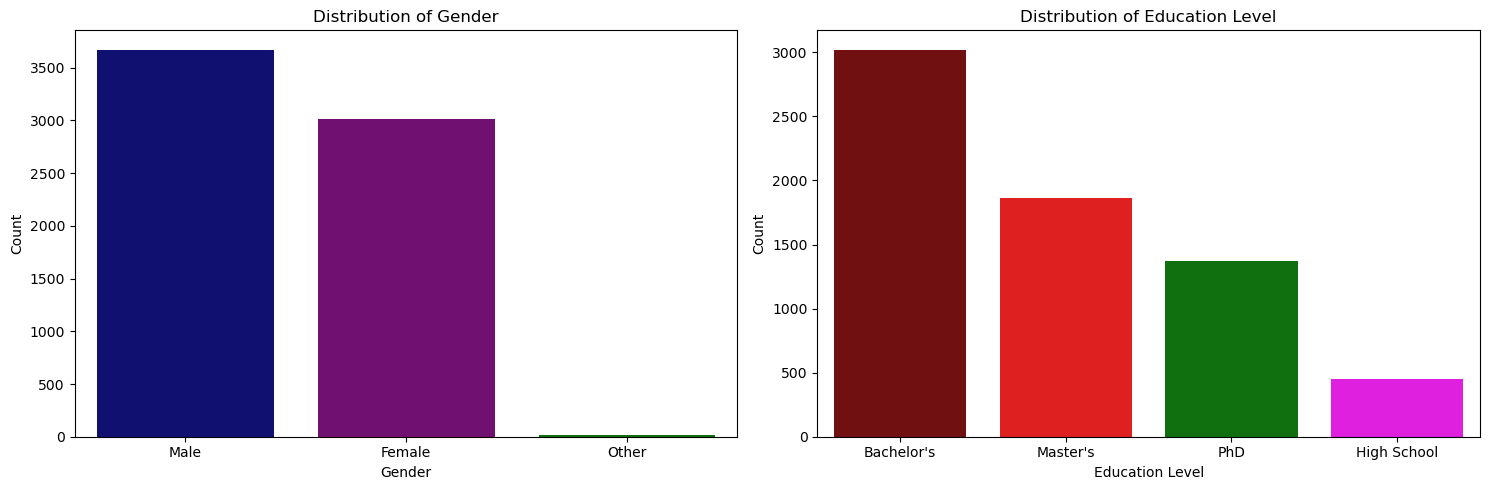

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x='Gender', data=df, ax=ax[0],palette=['navy','purple','g'])
sns.countplot(x='Education_Level', data=df, ax=ax[1],palette=['maroon','r','g','magenta'])
ax[0].set_xlabel('Gender')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of Gender')
ax[1].set_xlabel('Education Level')
ax[1].set_ylabel('Count')
ax[1].set_title('Distribution of Education Level')

plt.tight_layout()
plt.show()

In [20]:
# 1.More male workers
# 2. Most people have a Bachelor's degree

In [21]:
top_10_highest_paying_jobs = df.groupby('Job_Title')['Salary'].mean().nlargest(10)

In [22]:
top_10_highest_paying_jobs

Job_Title
Director of Data Science     204561.403509
Marketing Director           183984.375000
Software Engineer Manager    172502.167553
Senior Project Engineer      166224.754717
Data Scientist               166105.960265
Research Scientist           165362.318841
Research Director            163333.333333
Senior Software Engineer     151326.688525
Senior Data Scientist        151147.540984
Financial Manager            143059.701493
Name: Salary, dtype: float64

C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1993463327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_highest_paying_jobs.index, y=top_10_highest_paying_jobs.values,palette=['b','orange','g','r','navy','purple',
C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1993463327.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


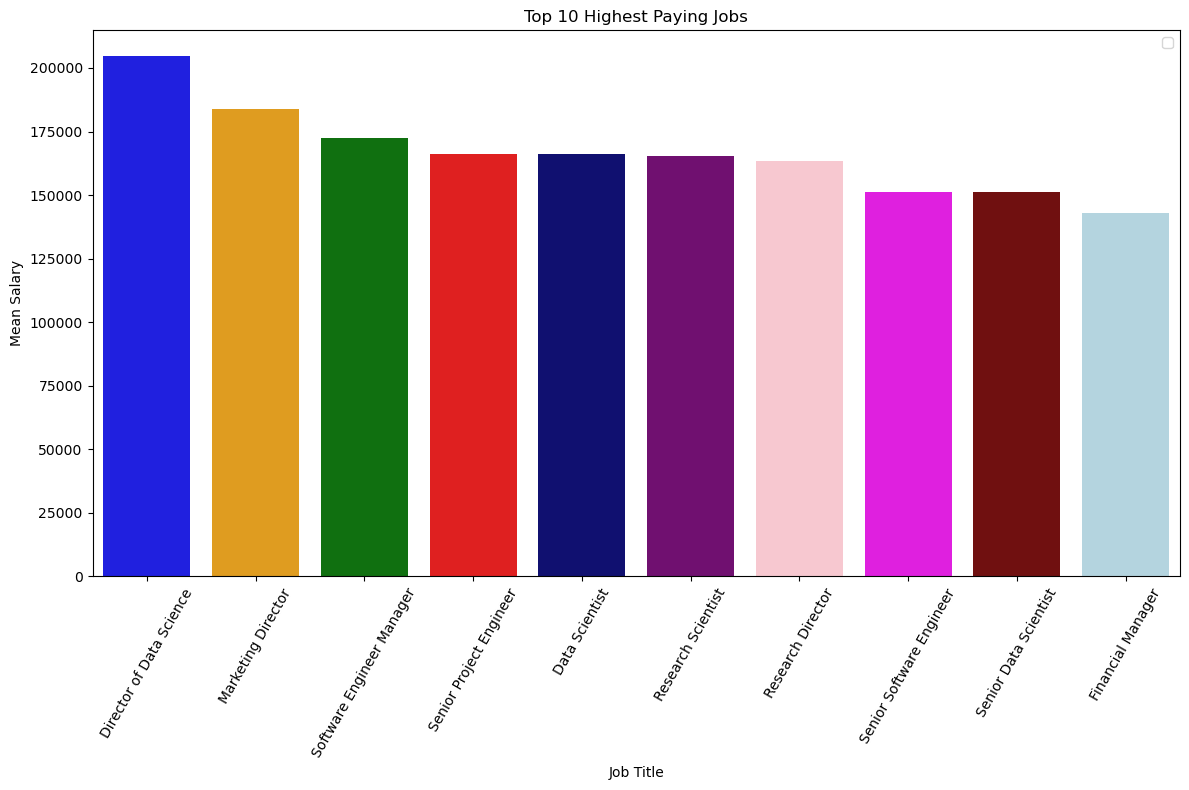

In [23]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_highest_paying_jobs.index, y=top_10_highest_paying_jobs.values,palette=['b','orange','g','r','navy','purple',
                                                                                            'pink','magenta','maroon','lightblue'])
plt.xlabel('Job Title')
plt.ylabel('Mean Salary')
plt.title('Top 10 Highest Paying Jobs')
plt.xticks(rotation=60)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [24]:
corr_matrix=df._get_numeric_data().corr()
corr_matrix

,Age,Years_of_Experience,Salary
Age,1.000000,0.937725,0.728061
Years_of_Experience,0.937725,1.000000,0.808968
Salary,0.728061,0.808968,1.000000


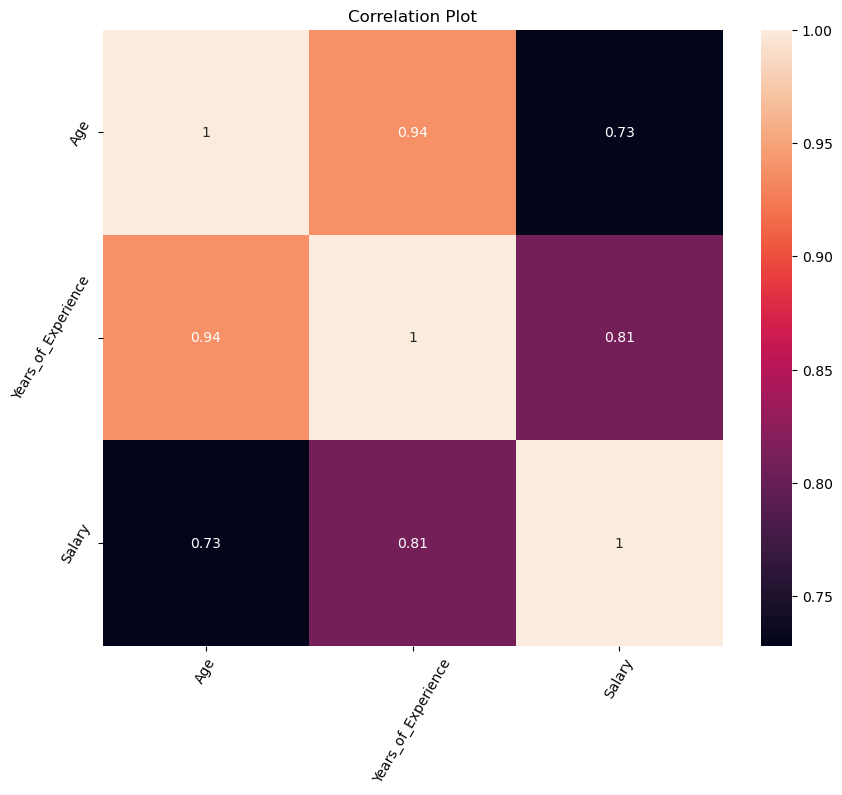

In [25]:
plt.figure(figsize=(10, 8))  
sns.heatmap(corr_matrix, annot=True)  
plt.title('Correlation Plot')
plt.xticks(rotation=60) 
plt.yticks(rotation=60) 
plt.show()

Highest correlation between age and years of experience

High correlation between salary and years of experience

High correlation between salary and age

C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1554514989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Salary', data=df, ax=ax[0],palette=['r','g','b'])
C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1554514989.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Education_Level', y='Salary', data=df, ax=ax[1],palette=['r','g','b'])
C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1554514989.py:4: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Education_Level', y='Salary', data=df, ax=ax[1],palette=['r','g','b'])
C:\Users\hashr\AppData\Local\Temp\ipykernel_39332\1

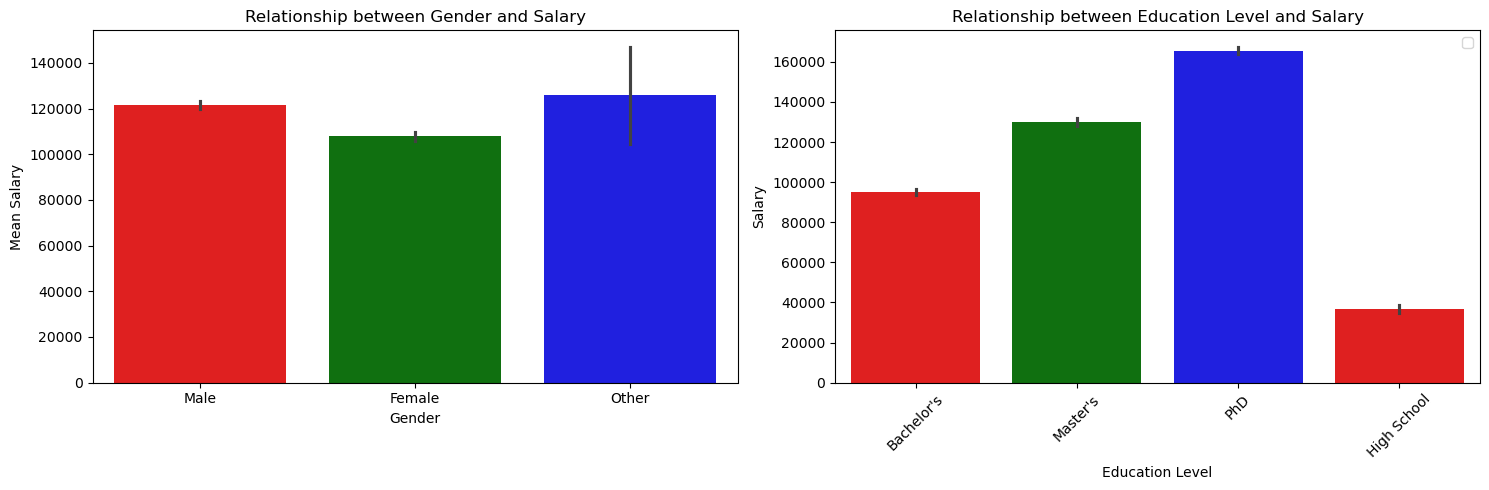

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x='Gender', y='Salary', data=df, ax=ax[0],palette=['r','g','b'])
ax[0].set(title='Relationship between Gender and Salary', xlabel='Gender', ylabel='Mean Salary')
sns.barplot(x='Education_Level', y='Salary', data=df, ax=ax[1],palette=['r','g','b'])
ax[1].set(title='Relationship between Education Level and Salary', xlabel='Education Level', ylabel='Salary')
ax[1].tick_params(axis='x', rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Others earn more salary compared to both male and female

From the above bar chart As Education level increases, Salary also increases

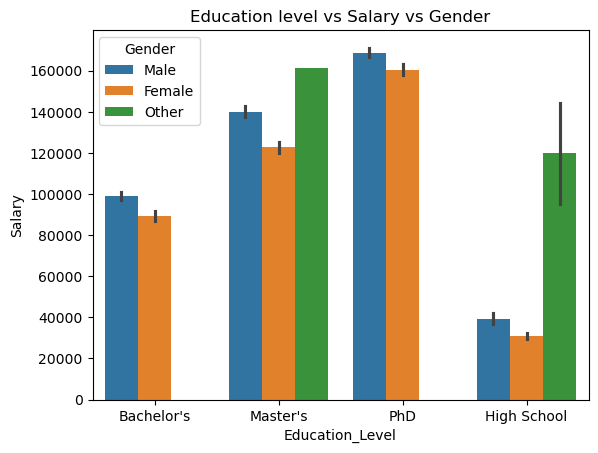

In [27]:
sns.barplot(x='Education_Level',y='Salary',data=df,hue='Gender')
plt.title('Education level vs Salary vs Gender')
plt.show()

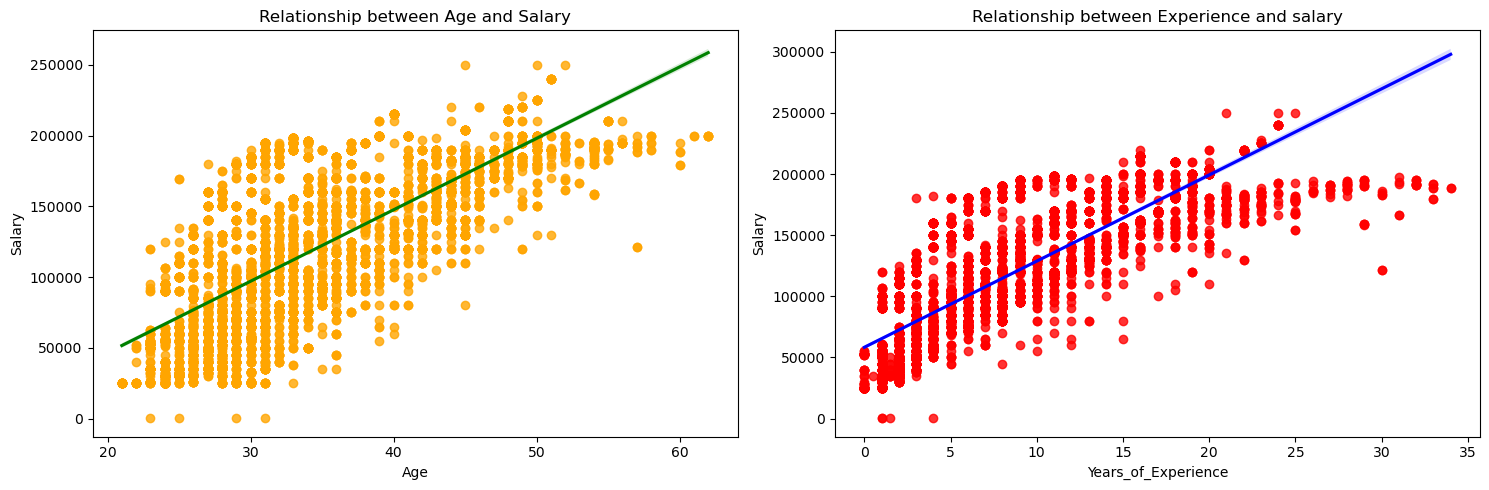

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(x='Age',y='Salary',data=df, scatter_kws={'color':'orange'}, line_kws={'color':'green'}, ax=ax[0])
ax[0].set(title='Relationship between Age and Salary')
sns.regplot(x='Years_of_Experience',y='Salary',data=df, scatter_kws={'color':'red'}, line_kws={'color':'blue'}, ax=ax[1])
ax[1].set(title='Relationship between Experience and salary')
plt.tight_layout()
plt.show()

# ML MODELS

1. Linear Regression

2. Decision Tree

3. Random Forest

In [29]:
# Since Gender and Educational_Level are Categorical, we need to convert into numericals by applying label encoding

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [31]:
cat_cols = ['Job_Title', 'Gender', 'Education_Level']
encoders = {}

df_encoded = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])  # transform into integers for training
    encoders[col] = le  # store encoder with string classes

In [32]:
X = df_encoded.drop('Salary', axis=1)
y = df_encoded['Salary']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred = model.predict(X_test)

In [37]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [38]:
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2:.3f}")

Mean Squared Error (MSE): 898034233.8834084
Mean Absolute Error (MAE): 23570.213513170882
Root Mean Squared Error (RMSE): 29967.219321842465
R² Score: 0.685


2.Decision Tree

In [39]:
dt_model = DecisionTreeRegressor(random_state=42)

In [40]:
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [41]:
y_pred_dt = dt_model.predict(X_test)

In [42]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = dt_model.score(X_test, y_test)

In [43]:
print("Decision Tree Regression:")
print(f"MSE: {mse_dt}, MAE: {mae_dt},  R²: {r2_dt}")

Decision Tree Regression:
MSE: 114075316.53257541, MAE: 3484.532232657659,  R²: 0.9599940568709373


3.Random Forest

In [44]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [45]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [46]:
y_pred_rf = rf_model.predict(X_test)

In [47]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = rf_model.score(X_test, y_test)

In [48]:
print("Random Forest Regression:")
print(f"MSE: {mse_rf}, MAE: {mae_rf}, R²: {r2_rf}")

Random Forest Regression:
MSE: 79028615.90118377, MAE: 3399.4988752544164, R²: 0.972284851715415


4.XGBoost

In [49]:
import xgboost as xgb

In [50]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [51]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [52]:
y_pred = model.predict(X_test)

In [53]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [54]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 5108.71
RMSE: 9186.09
MSE: 84384314.33
R²: 0.970


In [55]:

# -----------------------------
# 1️⃣ Define models
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
}

# -----------------------------
# 2️⃣ Train, Predict, Evaluate
# -----------------------------
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Train metrics
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    
    # Test metrics
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    results.append({
        "Model": name,
        "Train RMSE": rmse_train,
        "Test RMSE": rmse_test,
        "Train MAE": mae_train,
        "Test MAE": mae_test,
        "Train R²": r2_train,
        "Test R²": r2_test
    })

# -----------------------------
# 3️⃣ Display results
# -----------------------------
results_df = pd.DataFrame(results)
print(results_df)

               Model    Train RMSE     Test RMSE     Train MAE      Test MAE  \
0  Linear Regression  29863.435951  29967.219322  23632.719964  23570.213513   
1      Decision Tree   4329.429264  10680.604689   1222.901107   3484.532233   
2      Random Forest   4929.732409   8889.804042   1866.161905   3399.498875   
3            XGBoost   7093.086150   9186.093530   4121.106570   5108.713752   

   Train R²   Test R²  
0  0.678035  0.685062  
1  0.993233  0.959994  
2  0.991226  0.972285  
3  0.981836  0.970407  


# The Random Forest model achieved the highest R-squared score (0.973) and the lowest MSE, MAE, values, indicating the best predictive performance among the three models.

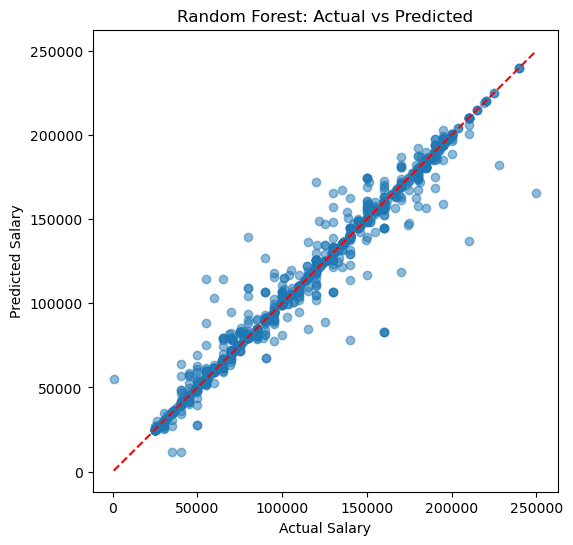

In [56]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [57]:
import joblib
rf_model.fit(X_train,y_train)
joblib.dump(rf_model, "salary_model.pkl")

['salary_model.pkl']

In [58]:
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']